# 05 — Predictive Maintenance

**Objective:** Build a data-driven predictive maintenance pipeline for a 180-miner Bitcoin mining site.  
We analyze 14 days of 5-minute telemetry to:

1. Engineer daily miner health profiles with trend features  
2. Detect degrading miners via unsupervised methods (linear regression slopes, composite scoring)  
3. Score anomaly risk with Isolation Forest  
4. Analyze failure precursor patterns  
5. Train a supervised model to predict failures 48 hours ahead  
6. Produce a prioritized maintenance action list with cost-of-inaction estimates  

All degrading/failing miners are **discovered from the data**, not hardcoded.

---
## 1. Load & Prep

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (14, 6)

# --- BTC economics for cost-of-inaction estimates ---
BTC_PRICE_USD = 84_000        # approximate BTC price
NETWORK_HASHRATE_EH = 800     # EH/s
BLOCK_REWARD_BTC = 3.125      # post-halving
BLOCKS_PER_DAY = 144

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load telemetry
telem = pd.read_csv(
    'site_telemetry.csv',
    na_values=[''],
    parse_dates=['timestamp']
)

# Load miner registry
registry = pd.read_csv('miner_registry.csv')

print(f'Telemetry: {telem.shape[0]:,} rows, {telem.shape[1]} columns')
print(f'Registry:  {registry.shape[0]} miners')
print(f'Date range: {telem.timestamp.min()} to {telem.timestamp.max()}')
print(f'\nStatus counts:\n{telem.status.value_counts()}')
print(f'\nModels in registry:\n{registry.model.value_counts()}')

Telemetry: 725,760 rows, 21 columns
Registry:  180 miners
Date range: 2026-04-09 00:00:00 to 2026-04-22 23:55:00

Status counts:
status
mining     723533
offline      2142
error          85
Name: count, dtype: int64

Models in registry:
model
S21      75
S19XP    65
M63      30
M56S     10
Name: count, dtype: int64


In [3]:
# Merge telemetry with registry to get nominal specs
df = telem.merge(
    registry[['miner_id', 'nominal_hashrate_th', 'nominal_power_w', 'nominal_efficiency_wth', 'cooling']],
    on='miner_id',
    how='left'
)

# Add date column for daily aggregation
df['date'] = df['timestamp'].dt.date

# Quick sanity check on nulls
null_pct = df.isnull().mean().sort_values(ascending=False)
print('Columns with >0% null:')
print(null_pct[null_pct > 0].apply(lambda x: f'{x:.2%}'))

Columns with >0% null:
chip_temp_c        1.28%
efficiency_wth     1.28%
board_temp_c       1.28%
hashrate_th_5m     0.99%
accepted_shares    0.99%
rejected_shares    0.99%
fan_speed_rpm      0.99%
stale_shares       0.99%
power_w            0.99%
hashrate_th_avg    0.99%
frequency_mhz      0.99%
dtype: str


---
## 2. Feature Engineering — Daily Miner Profiles

In [4]:
# Only aggregate from rows where the miner is actually mining
mining = df[df['status'] == 'mining'].copy()

# --- Per-miner, per-day aggregation ---
agg_dict = {
    'hashrate_th_5m': ['mean', 'std', 'min', 'max'],
    'efficiency_wth': ['mean', 'std', 'min', 'max'],
    'chip_temp_c':    ['mean', 'std', 'min', 'max'],
    'power_w':        ['mean', 'std', 'min', 'max'],
    'accepted_shares': 'sum',
    'rejected_shares': 'sum',
    'stale_shares':    'sum',
    'fan_speed_rpm':   'mean',
}

daily_mining = mining.groupby(['miner_id', 'date']).agg(agg_dict)
daily_mining.columns = ['_'.join(col).strip() for col in daily_mining.columns]
daily_mining = daily_mining.reset_index()

# --- Downtime: count offline/error intervals per miner per day ---
downtime = (
    df[df['status'].isin(['offline', 'error'])]
    .groupby(['miner_id', 'date'])
    .size()
    .reset_index(name='downtime_intervals')
)
downtime['downtime_hours'] = downtime['downtime_intervals'] * 5 / 60

# Merge downtime into daily profiles
daily = daily_mining.merge(downtime[['miner_id', 'date', 'downtime_hours']], 
                           on=['miner_id', 'date'], how='left')
daily['downtime_hours'] = daily['downtime_hours'].fillna(0)

# --- Derived features ---
daily['total_shares'] = daily['accepted_shares_sum'] + daily['rejected_shares_sum'] + daily['stale_shares_sum']
daily['rejection_rate'] = np.where(
    daily['total_shares'] > 0,
    (daily['rejected_shares_sum'] + daily['stale_shares_sum']) / daily['total_shares'],
    0
)

# Merge nominal specs for ratio features
daily = daily.merge(
    registry[['miner_id', 'nominal_hashrate_th', 'nominal_efficiency_wth', 'model']],
    on='miner_id', how='left'
)

daily['hashrate_vs_nominal'] = daily['hashrate_th_5m_mean'] / daily['nominal_hashrate_th']
daily['efficiency_gap'] = daily['efficiency_wth_mean'] - daily['nominal_efficiency_wth']

print(f'Daily profiles: {daily.shape[0]:,} rows ({daily.miner_id.nunique()} miners x {daily.date.nunique()} days)')
daily.head(3)

Daily profiles: 2,514 rows (180 miners x 14 days)


,miner_id,date,hashrate_th_5m_mean,hashrate_th_5m_std,hashrate_th_5m_min,hashrate_th_5m_max,efficiency_wth_mean,efficiency_wth_std,efficiency_wth_min,efficiency_wth_max,...,stale_shares_sum,fan_speed_rpm_mean,downtime_hours,total_shares,rejection_rate,nominal_hashrate_th,nominal_efficiency_wth,model,hashrate_vs_nominal,efficiency_gap
0,MNR-0001,2026-04-09,199.287273,2.903192,190.55,207.63,17.486748,0.307472,16.70,18.40,...,0.0,4044.444056,0.0,995.0,0.0,200,17.5,S21,0.996436,-0.013252
1,MNR-0001,2026-04-10,198.698339,3.282298,189.06,207.58,17.518445,0.337892,16.66,18.53,...,0.0,4129.929329,0.0,979.0,0.0,200,17.5,S21,0.993492,0.018445
2,MNR-0001,2026-04-11,198.769301,3.377229,186.44,206.30,17.514825,0.355584,16.72,18.78,...,0.0,4194.402098,0.0,974.0,0.0,200,17.5,S21,0.993847,0.014825


In [5]:
# --- TREND features per miner (slopes over time) ---

def compute_slope(series):
    """OLS slope of series vs integer index. Returns slope and p-value."""
    y = series.dropna().values
    if len(y) < 3:
        return np.nan, np.nan
    x = np.arange(len(y))
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    return slope, p_value

daily_sorted = daily.sort_values(['miner_id', 'date'])

trends = []
for miner_id, group in daily_sorted.groupby('miner_id'):
    hr_slope, hr_pval = compute_slope(group['hashrate_th_5m_mean'])
    eff_slope, eff_pval = compute_slope(group['efficiency_wth_mean'])
    temp_slope, temp_pval = compute_slope(group['chip_temp_c_mean'])
    var_slope, var_pval = compute_slope(group['hashrate_th_5m_std'])
    
    trends.append({
        'miner_id': miner_id,
        'hashrate_slope': hr_slope,
        'hashrate_slope_pval': hr_pval,
        'efficiency_slope': eff_slope,
        'efficiency_slope_pval': eff_pval,
        'temp_slope': temp_slope,
        'temp_slope_pval': temp_pval,
        'variability_trend': var_slope,
        'variability_trend_pval': var_pval,
    })

trends_df = pd.DataFrame(trends)

# Merge trends into daily profiles (same trend per miner across all days)
daily = daily.merge(trends_df, on='miner_id', how='left')

print(f'Trend features computed for {len(trends_df)} miners')
trends_df.sort_values('hashrate_slope').head(10)

Trend features computed for 180 miners


,miner_id,hashrate_slope,hashrate_slope_pval,efficiency_slope,efficiency_slope_pval,temp_slope,temp_slope_pval,variability_trend,variability_trend_pval
169,MNR-0170,-1.398748,5.320532e-09,0.143911,9.335844e-09,-0.320381,0.001978,-0.436144,0.001710
97,MNR-0098,-0.938659,2.856742e-09,0.094461,6.740451e-09,-0.322376,0.001489,-0.248722,0.005328
37,MNR-0038,-0.000287,9.866414e-01,0.000093,9.563341e-01,-0.324391,0.001492,-0.036009,0.084079
7,MNR-0008,0.007712,7.054405e-01,-0.001345,4.983163e-01,-0.324224,0.001726,-0.036588,0.069699
24,MNR-0025,0.011560,5.380169e-01,-0.001170,4.915866e-01,-0.319236,0.001891,-0.039855,0.081475
31,MNR-0032,0.011715,6.040505e-01,-0.002220,3.733835e-01,-0.319292,0.001897,-0.027726,0.258796
30,MNR-0031,0.015342,4.770406e-01,-0.001107,5.959324e-01,-0.327273,0.001570,-0.046830,0.051624
45,MNR-0046,0.018002,7.449756e-01,-0.001667,5.104948e-01,-0.320651,0.001528,-0.071815,0.185036
56,MNR-0057,0.018222,7.360683e-01,-0.001368,6.233726e-01,-0.325361,0.001363,-0.069898,0.129001
10,MNR-0011,0.020964,2.292079e-01,-0.002907,1.063207e-01,-0.319354,0.001633,-0.022965,0.317143


---
## 3. Degradation Detection — Unsupervised

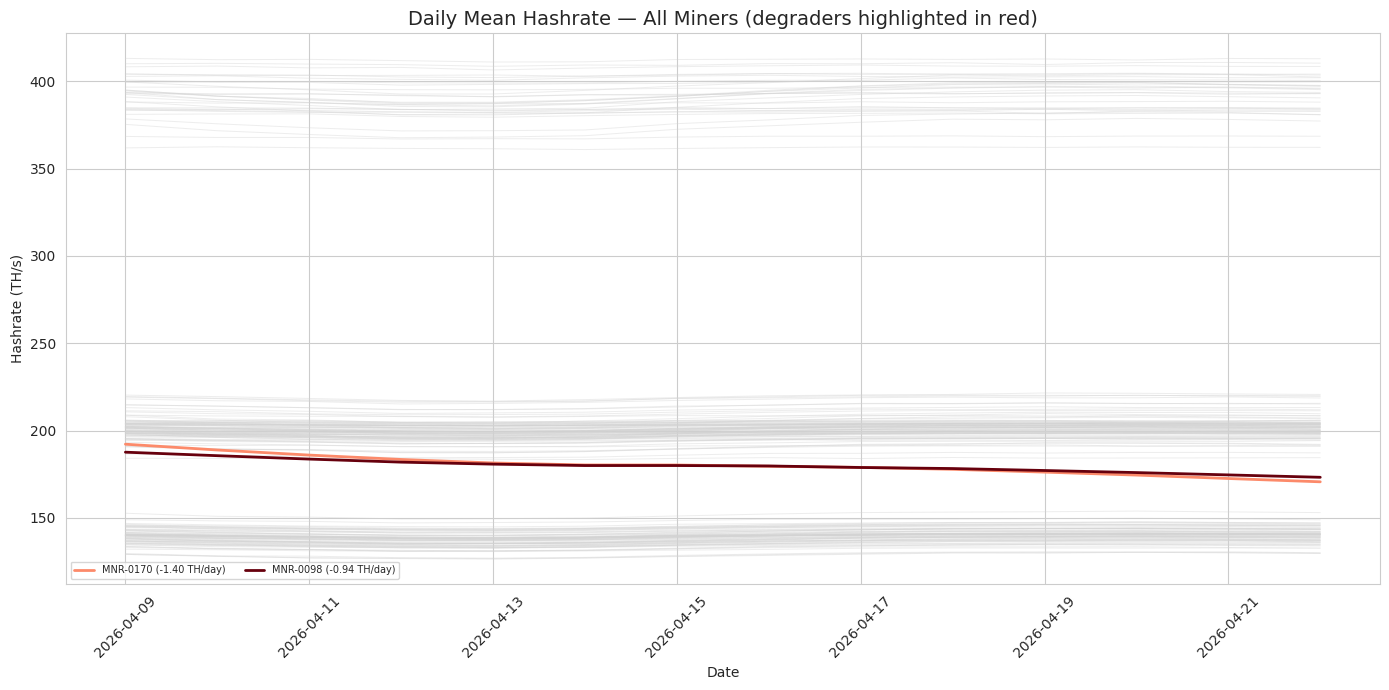

In [6]:
# --- 3a. Visual: daily hashrate overlay colored by degradation ---

fig, ax = plt.subplots(figsize=(14, 7))

# Plot all miners as thin gray lines
for miner_id, grp in daily_sorted.groupby('miner_id'):
    ax.plot(grp['date'], grp['hashrate_th_5m_mean'], color='lightgray', alpha=0.4, linewidth=0.7)

# Highlight the worst degraders (steepest negative hashrate slopes with p < 0.05)
sig_degraders = trends_df[
    (trends_df['hashrate_slope'] < 0) & (trends_df['hashrate_slope_pval'] < 0.05)
].nsmallest(15, 'hashrate_slope')

colors = plt.cm.Reds(np.linspace(0.4, 1.0, len(sig_degraders)))
for (_, row), c in zip(sig_degraders.iterrows(), colors):
    grp = daily_sorted[daily_sorted['miner_id'] == row['miner_id']]
    ax.plot(grp['date'], grp['hashrate_th_5m_mean'], color=c, linewidth=2,
            label=f"{row['miner_id']} ({row['hashrate_slope']:.2f} TH/day)")

ax.set_title('Daily Mean Hashrate — All Miners (degraders highlighted in red)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Hashrate (TH/s)')
ax.legend(fontsize=7, loc='lower left', ncol=2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

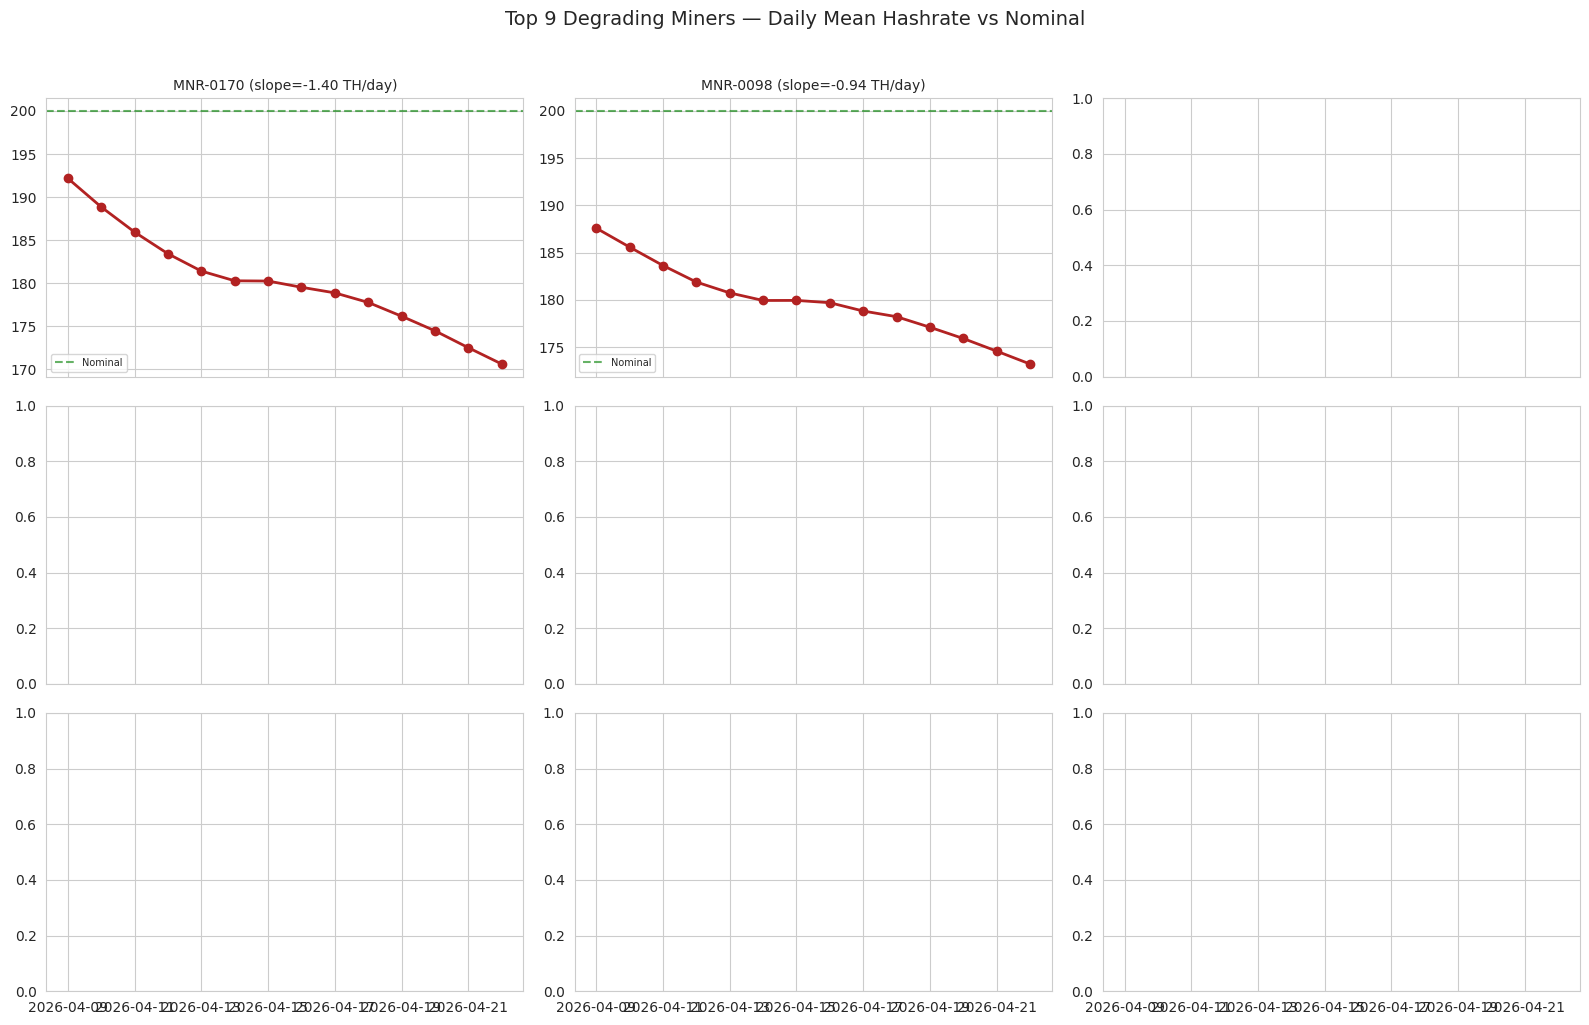

In [7]:
# --- 3b. Small multiples for top degraders ---

top_degraders = sig_degraders.head(9)['miner_id'].tolist()

fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=True)
axes_flat = axes.flatten()

for i, mid in enumerate(top_degraders):
    ax = axes_flat[i]
    grp = daily_sorted[daily_sorted['miner_id'] == mid]
    ax.plot(grp['date'], grp['hashrate_th_5m_mean'], 'o-', color='firebrick', linewidth=2)
    nominal = grp['nominal_hashrate_th'].iloc[0]
    ax.axhline(nominal, color='green', linestyle='--', alpha=0.6, label='Nominal')
    slope = trends_df.loc[trends_df['miner_id'] == mid, 'hashrate_slope'].iloc[0]
    ax.set_title(f'{mid} (slope={slope:.2f} TH/day)', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.legend(fontsize=7)

fig.suptitle('Top 9 Degrading Miners — Daily Mean Hashrate vs Nominal', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

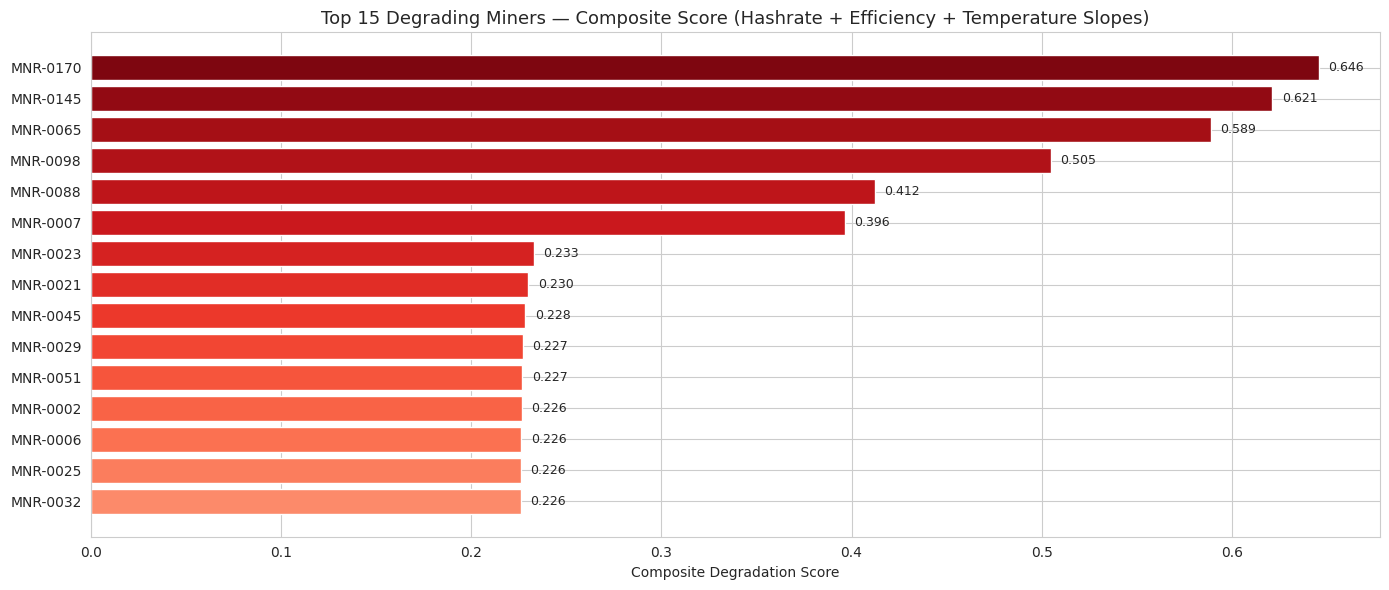


Top 15 degrading miners:
miner_id  hashrate_slope  efficiency_slope  temp_slope  degradation_score
MNR-0170       -1.398748          0.143911   -0.320381           0.645776
MNR-0145        0.255278          0.383987   -0.024991           0.621349
MNR-0065        0.140695          0.299907   -0.086627           0.589020
MNR-0098       -0.938659          0.094461   -0.322376           0.504844
MNR-0088        0.040180         -0.004090   -0.072911           0.412351
MNR-0007        0.024787          0.139380   -0.193690           0.396363
MNR-0023        0.051561         -0.005075   -0.281267           0.232828
MNR-0021        0.022972         -0.001762   -0.312666           0.229838
MNR-0045        0.067405         -0.002224   -0.315097           0.228419
MNR-0029        0.032782         -0.003407   -0.317484           0.227025
MNR-0051        0.073708         -0.004032   -0.317974           0.226739
MNR-0002        0.031240         -0.001977   -0.318568           0.226392
MNR-0006    

In [8]:
# --- 3c. Composite Degradation Score ---
#
# Combine three signals into a single degradation score:
#   - hashrate_slope (negative = bad)  -> invert so larger = worse
#   - efficiency_slope (positive = bad) -> already directionally correct
#   - temp_slope (positive = bad)       -> already directionally correct
#
# Only count slopes that are statistically significant (p < 0.05);
# non-significant slopes are zeroed out before scoring.

degrad = trends_df.copy()

# Zero out non-significant slopes
degrad['hr_sig'] = np.where(degrad['hashrate_slope_pval'] < 0.05, degrad['hashrate_slope'], 0)
degrad['eff_sig'] = np.where(degrad['efficiency_slope_pval'] < 0.05, degrad['efficiency_slope'], 0)
degrad['temp_sig'] = np.where(degrad['temp_slope_pval'] < 0.05, degrad['temp_slope'], 0)

# Normalize each component to [0, 1] using min-max, then combine
def minmax_scale(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn) if mx != mn else s * 0

# Invert hashrate (more negative = worse = higher score)
degrad['hr_score'] = minmax_scale(-degrad['hr_sig'])
degrad['eff_score'] = minmax_scale(degrad['eff_sig'])
degrad['temp_score'] = minmax_scale(degrad['temp_sig'])

# Weighted composite: hashrate drop is the strongest signal
degrad['degradation_score'] = (
    0.50 * degrad['hr_score'] +
    0.30 * degrad['eff_score'] +
    0.20 * degrad['temp_score']
)

degrad_ranked = degrad.sort_values('degradation_score', ascending=False)

# --- Bar chart: top 15 ---
top15 = degrad_ranked.head(15)

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.Reds(np.linspace(0.4, 0.95, 15))[::-1]
ax.barh(top15['miner_id'], top15['degradation_score'], color=colors)
ax.set_xlabel('Composite Degradation Score')
ax.set_title('Top 15 Degrading Miners — Composite Score (Hashrate + Efficiency + Temperature Slopes)', fontsize=13)
ax.invert_yaxis()
for i, (_, row) in enumerate(top15.iterrows()):
    ax.text(row['degradation_score'] + 0.005, i, f"{row['degradation_score']:.3f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nTop 15 degrading miners:')
print(top15[['miner_id', 'hashrate_slope', 'efficiency_slope', 'temp_slope', 'degradation_score']].to_string(index=False))

---
## 4. Anomaly-Based Risk Scoring — Isolation Forest

In [9]:
# --- 4a. Prepare feature matrix ---

iso_features = [
    'hashrate_th_5m_mean', 'hashrate_th_5m_std', 'hashrate_th_5m_min',
    'efficiency_wth_mean', 'efficiency_wth_std',
    'chip_temp_c_mean', 'chip_temp_c_max',
    'power_w_mean', 'power_w_std',
    'rejection_rate', 'downtime_hours',
    'fan_speed_rpm_mean',
    'hashrate_vs_nominal', 'efficiency_gap',
]

X_iso = daily[iso_features].copy()
X_iso = X_iso.fillna(X_iso.median())

scaler = StandardScaler()
X_iso_scaled = scaler.fit_transform(X_iso)

# --- Fit Isolation Forest ---
iso_model = IsolationForest(
    n_estimators=300,
    contamination=0.08,  # expect ~8% anomalous observations
    random_state=42,
    n_jobs=-1
)
iso_model.fit(X_iso_scaled)

# score_samples returns negative scores; more negative = more anomalous
# Convert to a risk_score in [0, 1] where 1 = highest risk
raw_scores = iso_model.score_samples(X_iso_scaled)
daily['iso_raw'] = raw_scores
daily['risk_score'] = minmax_scale(-raw_scores)  # invert so higher = riskier

print(f'Risk score stats:\n{daily["risk_score"].describe()}')
print(f'\nAnomalous observations (risk > 0.7): {(daily["risk_score"] > 0.7).sum()}')

Risk score stats:
count    2514.000000
mean        0.261814
std         0.199555
min         0.000000
25%         0.103029
50%         0.197169
75%         0.398599
max         1.000000
Name: risk_score, dtype: float64

Anomalous observations (risk > 0.7): 89


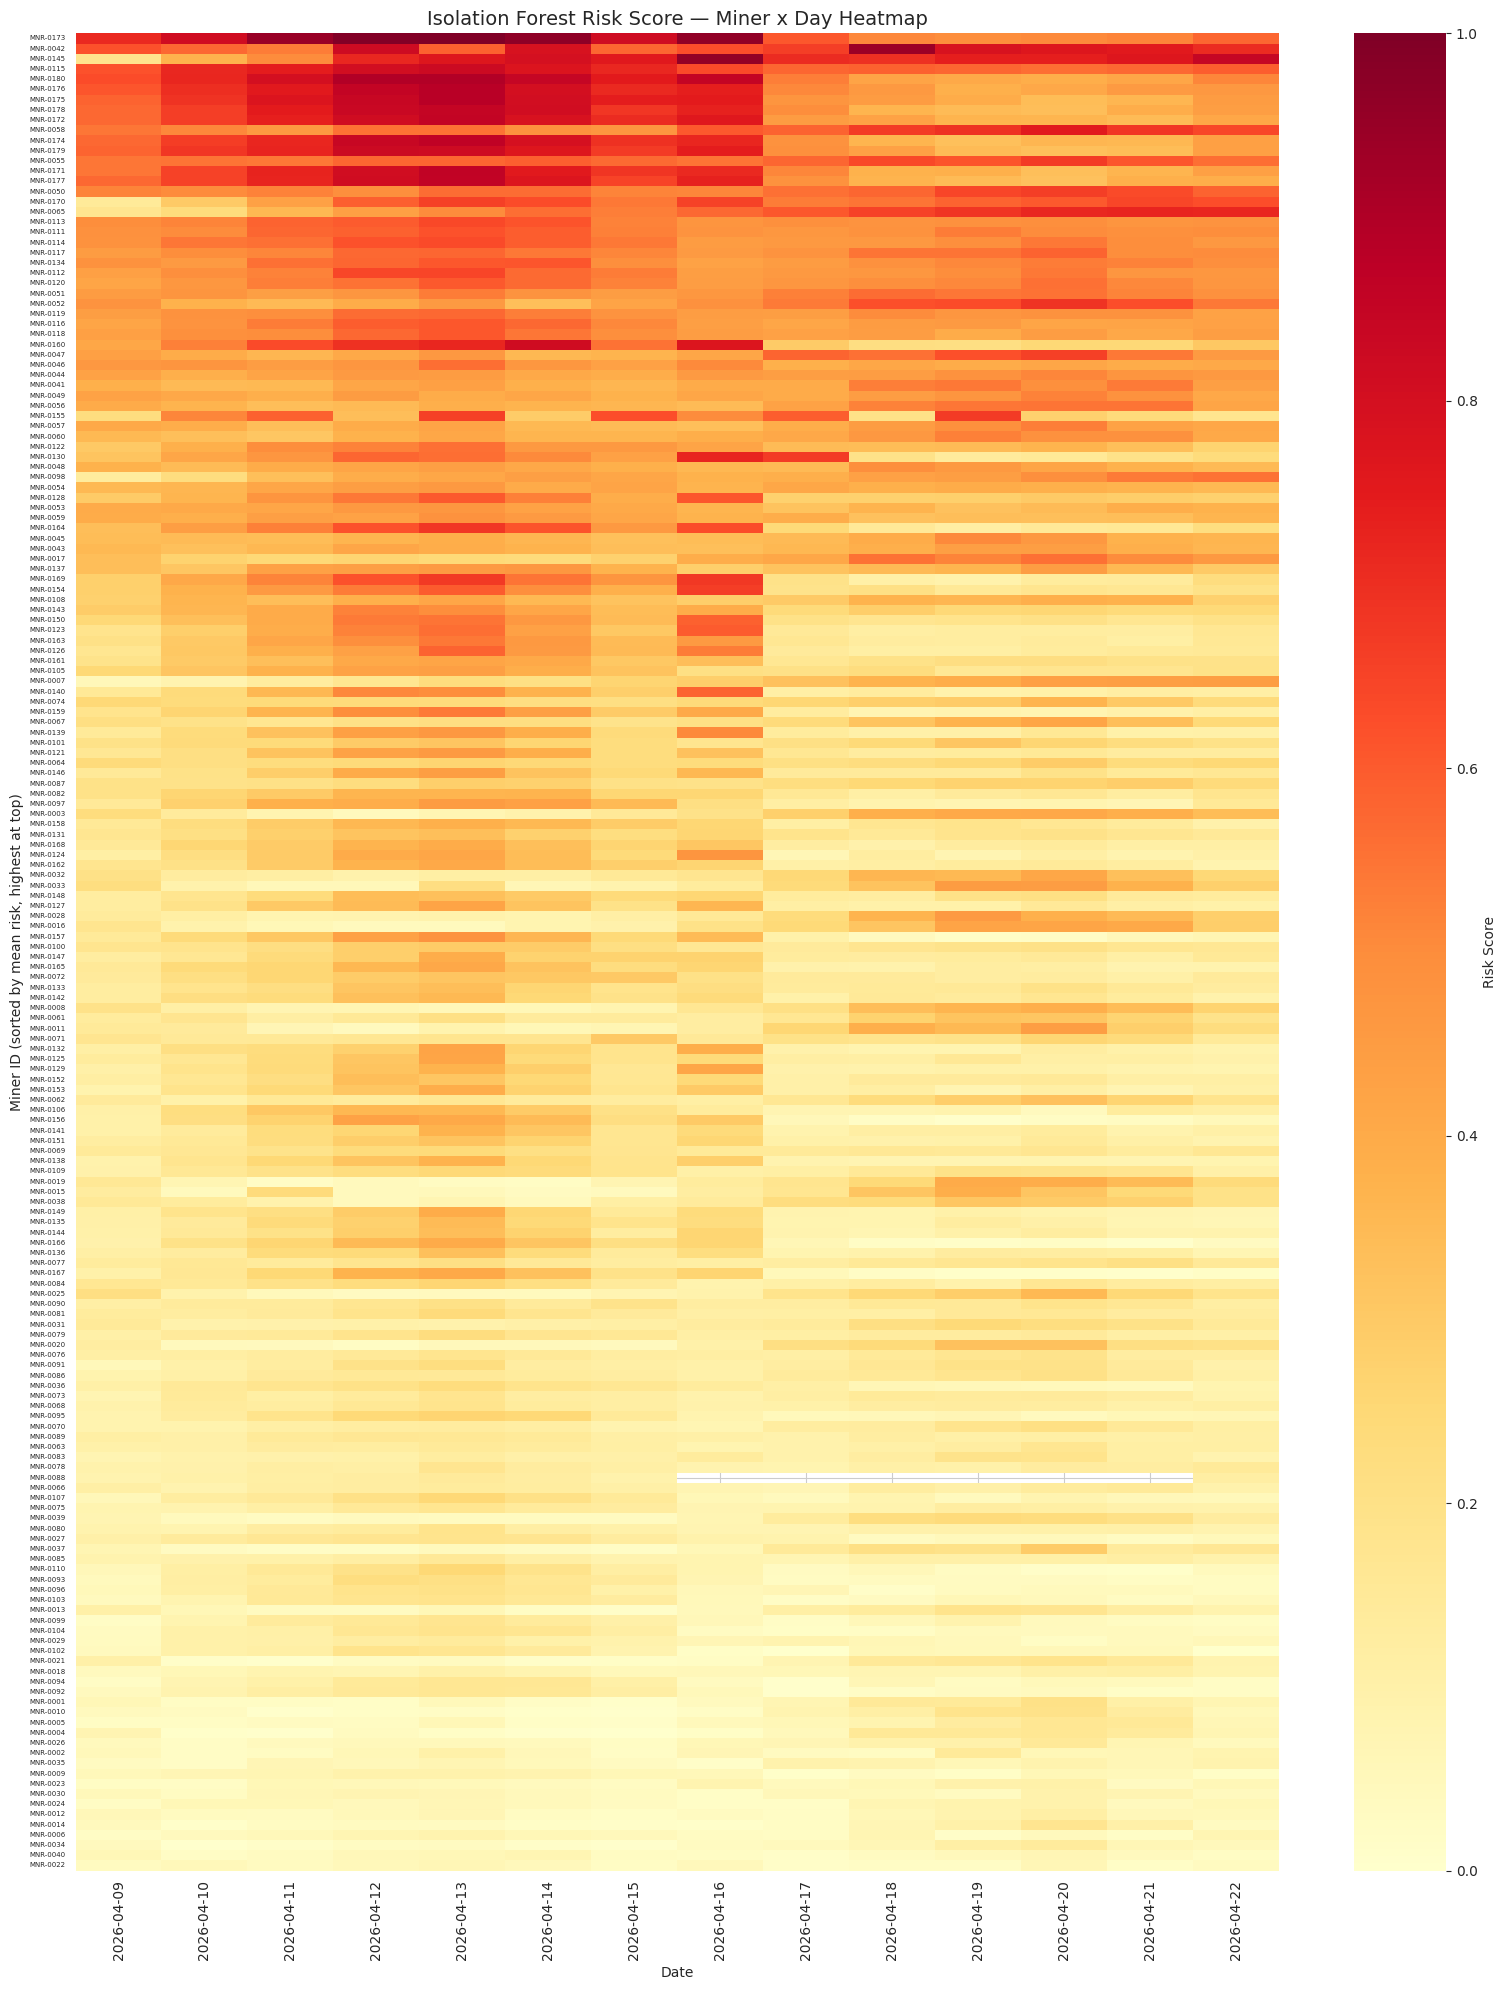

In [10]:
# --- 4b. Heatmap: miner x day, color = risk score ---

# Pivot to miner x date matrix
risk_pivot = daily.pivot_table(
    index='miner_id', columns='date', values='risk_score', aggfunc='mean'
)

# Sort miners by mean risk so the hottest are at top
risk_pivot = risk_pivot.loc[risk_pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(16, 20))
sns.heatmap(
    risk_pivot, cmap='YlOrRd', vmin=0, vmax=1,
    yticklabels=True, xticklabels=True,
    ax=ax, cbar_kws={'label': 'Risk Score'}
)
ax.set_title('Isolation Forest Risk Score — Miner x Day Heatmap', fontsize=14)
ax.set_ylabel('Miner ID (sorted by mean risk, highest at top)')
ax.set_xlabel('Date')
ax.tick_params(axis='y', labelsize=5)
plt.tight_layout()
plt.show()

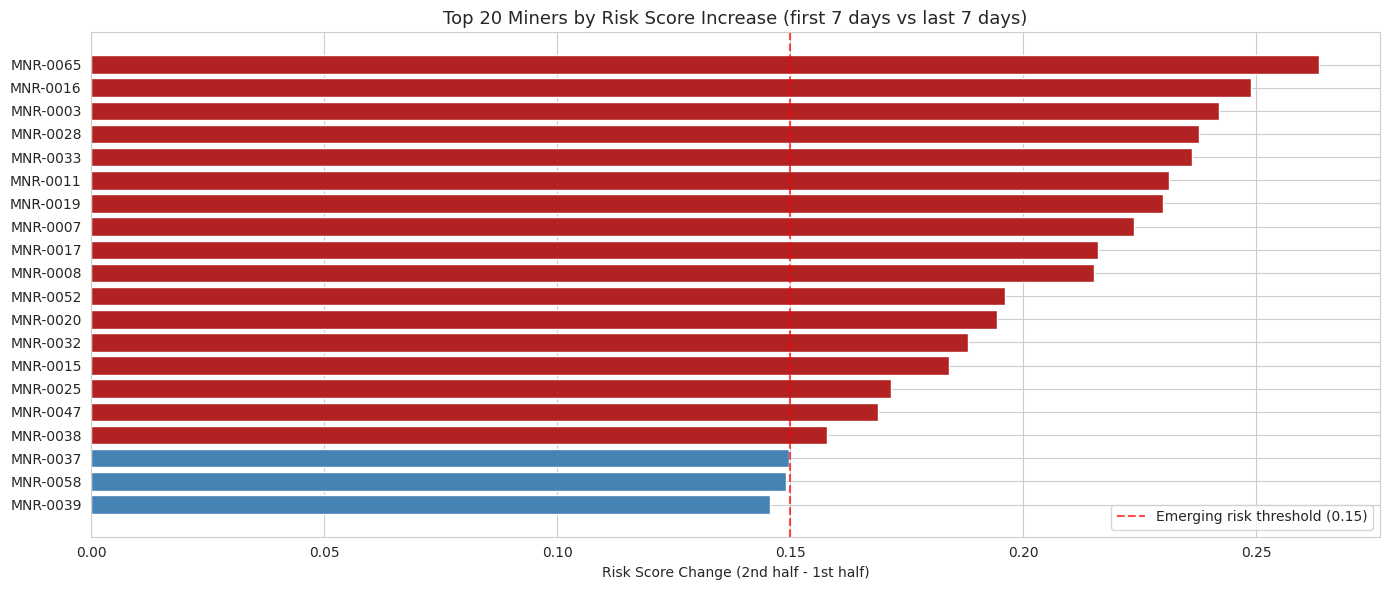


Miners with emerging risk (delta > 0.15): 17
miner_id
MNR-0065    0.263373
MNR-0016    0.248864
MNR-0003    0.241927
MNR-0028    0.237765
MNR-0033    0.236233
MNR-0011    0.231257
MNR-0019    0.230023
MNR-0007    0.223799
MNR-0017    0.215922
MNR-0008    0.215215
MNR-0052    0.196062
MNR-0020    0.194436
MNR-0032    0.188047
MNR-0015    0.184083
MNR-0025    0.171601
MNR-0047    0.168726
MNR-0038    0.157930


In [11]:
# --- 4c. Emerging risk: miners transitioning from low-risk to high-risk ---

dates = sorted(daily['date'].unique())
mid_point = dates[len(dates) // 2]

risk_first_half = daily[daily['date'] <= mid_point].groupby('miner_id')['risk_score'].mean()
risk_second_half = daily[daily['date'] > mid_point].groupby('miner_id')['risk_score'].mean()

risk_change = (risk_second_half - risk_first_half).dropna().sort_values(ascending=False)

# Flag miners with large risk increase
emerging_risk = risk_change[risk_change > 0.15]

fig, ax = plt.subplots(figsize=(14, 6))
top_emerging = risk_change.head(20)
colors = ['firebrick' if v > 0.15 else 'steelblue' for v in top_emerging.values]
ax.barh(top_emerging.index, top_emerging.values, color=colors)
ax.axvline(0.15, color='red', linestyle='--', alpha=0.7, label='Emerging risk threshold (0.15)')
ax.set_xlabel('Risk Score Change (2nd half - 1st half)')
ax.set_title('Top 20 Miners by Risk Score Increase (first 7 days vs last 7 days)', fontsize=13)
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nMiners with emerging risk (delta > 0.15): {len(emerging_risk)}')
print(emerging_risk.to_string())

---
## 5. Failure Pattern Analysis

In [12]:
# --- 5a. Find all miners that went offline/error ---

failure_events = df[df['status'].isin(['offline', 'error'])][['timestamp', 'miner_id', 'status']].copy()
failure_events = failure_events.sort_values(['miner_id', 'timestamp'])

# Get first failure per miner (onset of trouble)
first_failures = failure_events.groupby('miner_id')['timestamp'].min().reset_index()
first_failures.columns = ['miner_id', 'first_failure_ts']

failed_miners = first_failures['miner_id'].unique()
print(f'Miners that experienced offline/error events: {len(failed_miners)}')
print('Miners:', sorted(failed_miners))

Miners that experienced offline/error events: 21
Miners: ['MNR-0033', 'MNR-0042', 'MNR-0088', 'MNR-0123', 'MNR-0124', 'MNR-0126', 'MNR-0128', 'MNR-0129', 'MNR-0130', 'MNR-0132', 'MNR-0139', 'MNR-0140', 'MNR-0145', 'MNR-0150', 'MNR-0154', 'MNR-0155', 'MNR-0160', 'MNR-0164', 'MNR-0169', 'MNR-0173', 'MNR-0180']


In [13]:
# --- 5b. Extract pre-failure windows (24-48h before first failure) ---

pre_failure_records = []
for _, row in first_failures.iterrows():
    mid = row['miner_id']
    fail_ts = row['first_failure_ts']
    window_start = fail_ts - pd.Timedelta(hours=48)
    window_end = fail_ts - pd.Timedelta(minutes=5)  # just before failure
    
    pre = df[
        (df['miner_id'] == mid) &
        (df['timestamp'] >= window_start) &
        (df['timestamp'] <= window_end) &
        (df['status'] == 'mining')
    ].copy()
    pre['hours_before_failure'] = (fail_ts - pre['timestamp']).dt.total_seconds() / 3600
    pre['is_pre_failure'] = True
    pre_failure_records.append(pre)

pre_failure = pd.concat(pre_failure_records, ignore_index=True) if pre_failure_records else pd.DataFrame()
print(f'Pre-failure records: {len(pre_failure):,}')

Pre-failure records: 11,880


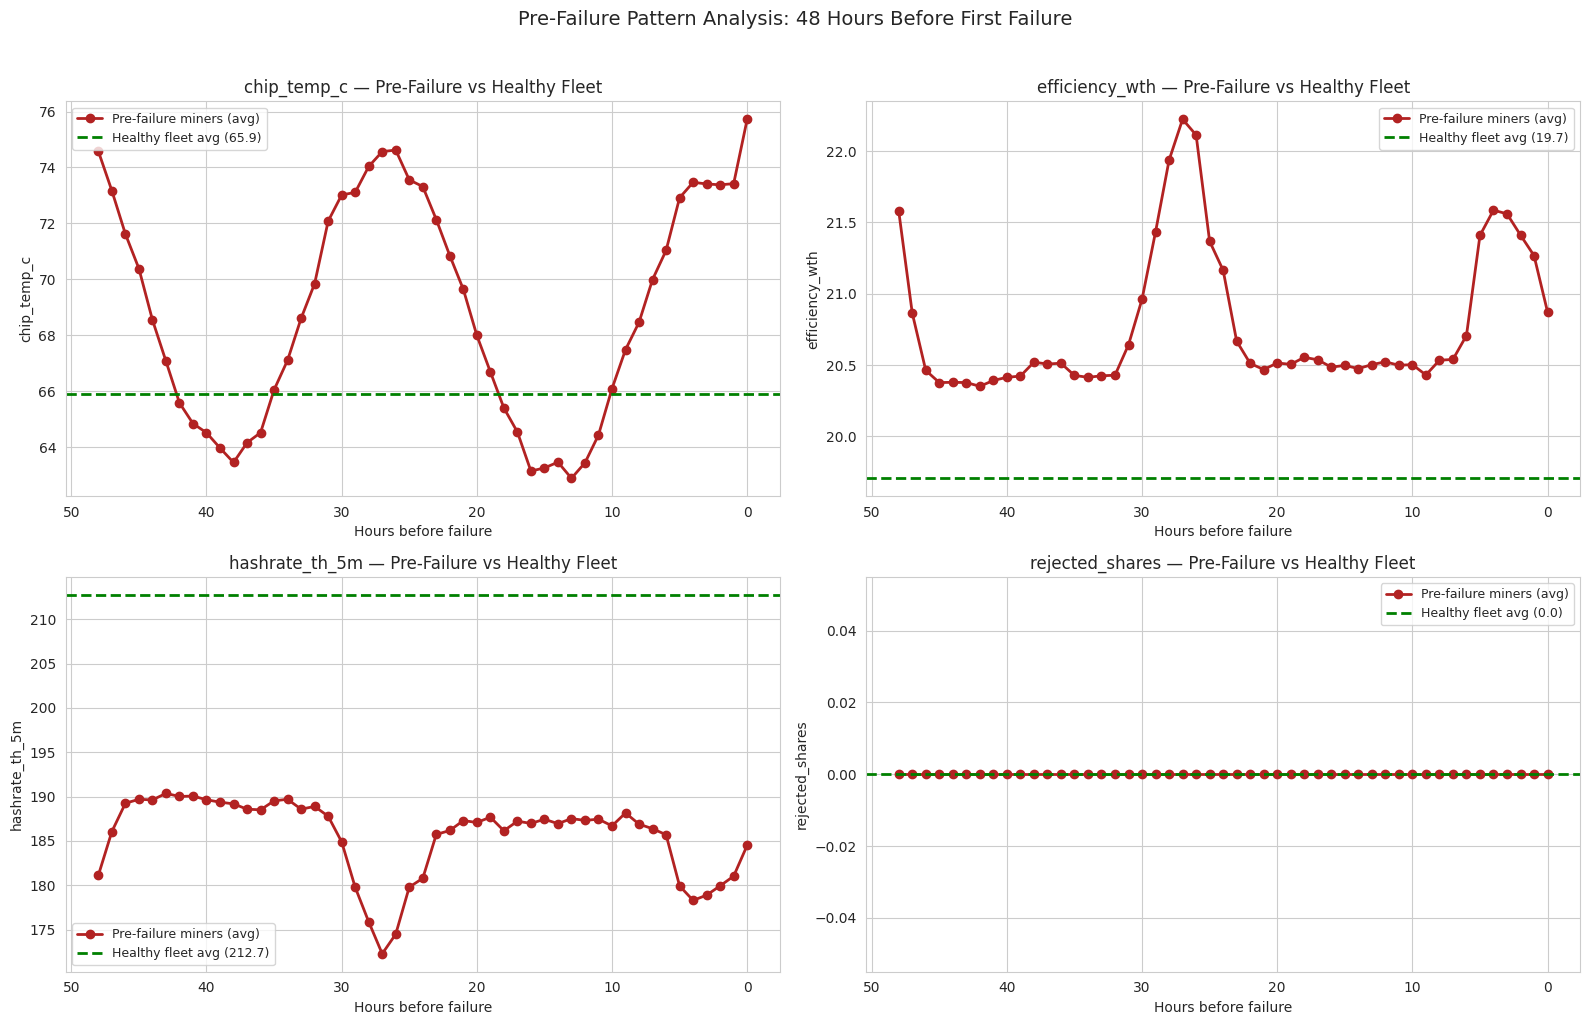

In [14]:
# --- 5c. Compare pre-failure metrics to healthy fleet at same timestamps ---

if len(pre_failure) > 0:
    # Get the timestamp range covered by pre-failure windows
    ts_min = pre_failure['timestamp'].min()
    ts_max = pre_failure['timestamp'].max()
    
    healthy_miners = set(df['miner_id'].unique()) - set(failed_miners)
    healthy_fleet = df[
        (df['miner_id'].isin(healthy_miners)) &
        (df['timestamp'] >= ts_min) &
        (df['timestamp'] <= ts_max) &
        (df['status'] == 'mining')
    ].copy()
    
    # Bin pre-failure data into hourly buckets before failure
    pre_failure['hour_bucket'] = pre_failure['hours_before_failure'].apply(lambda x: int(x))
    
    metrics_to_compare = ['chip_temp_c', 'efficiency_wth', 'hashrate_th_5m', 'rejected_shares']
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    for ax, metric in zip(axes.flatten(), metrics_to_compare):
        # Pre-failure: average per hour-bucket
        pf_hourly = pre_failure.groupby('hour_bucket')[metric].mean().sort_index(ascending=False)
        
        # Healthy fleet: overall average (flat baseline)
        healthy_avg = healthy_fleet[metric].mean()
        
        ax.plot(pf_hourly.index, pf_hourly.values, 'o-', color='firebrick', linewidth=2,
                label='Pre-failure miners (avg)')
        ax.axhline(healthy_avg, color='green', linestyle='--', linewidth=2,
                   label=f'Healthy fleet avg ({healthy_avg:.1f})')
        ax.set_xlabel('Hours before failure')
        ax.set_ylabel(metric)
        ax.set_title(f'{metric} — Pre-Failure vs Healthy Fleet')
        ax.invert_xaxis()  # 48h on left, 0h (failure) on right
        ax.legend(fontsize=9)
    
    fig.suptitle('Pre-Failure Pattern Analysis: 48 Hours Before First Failure', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No pre-failure records found.')

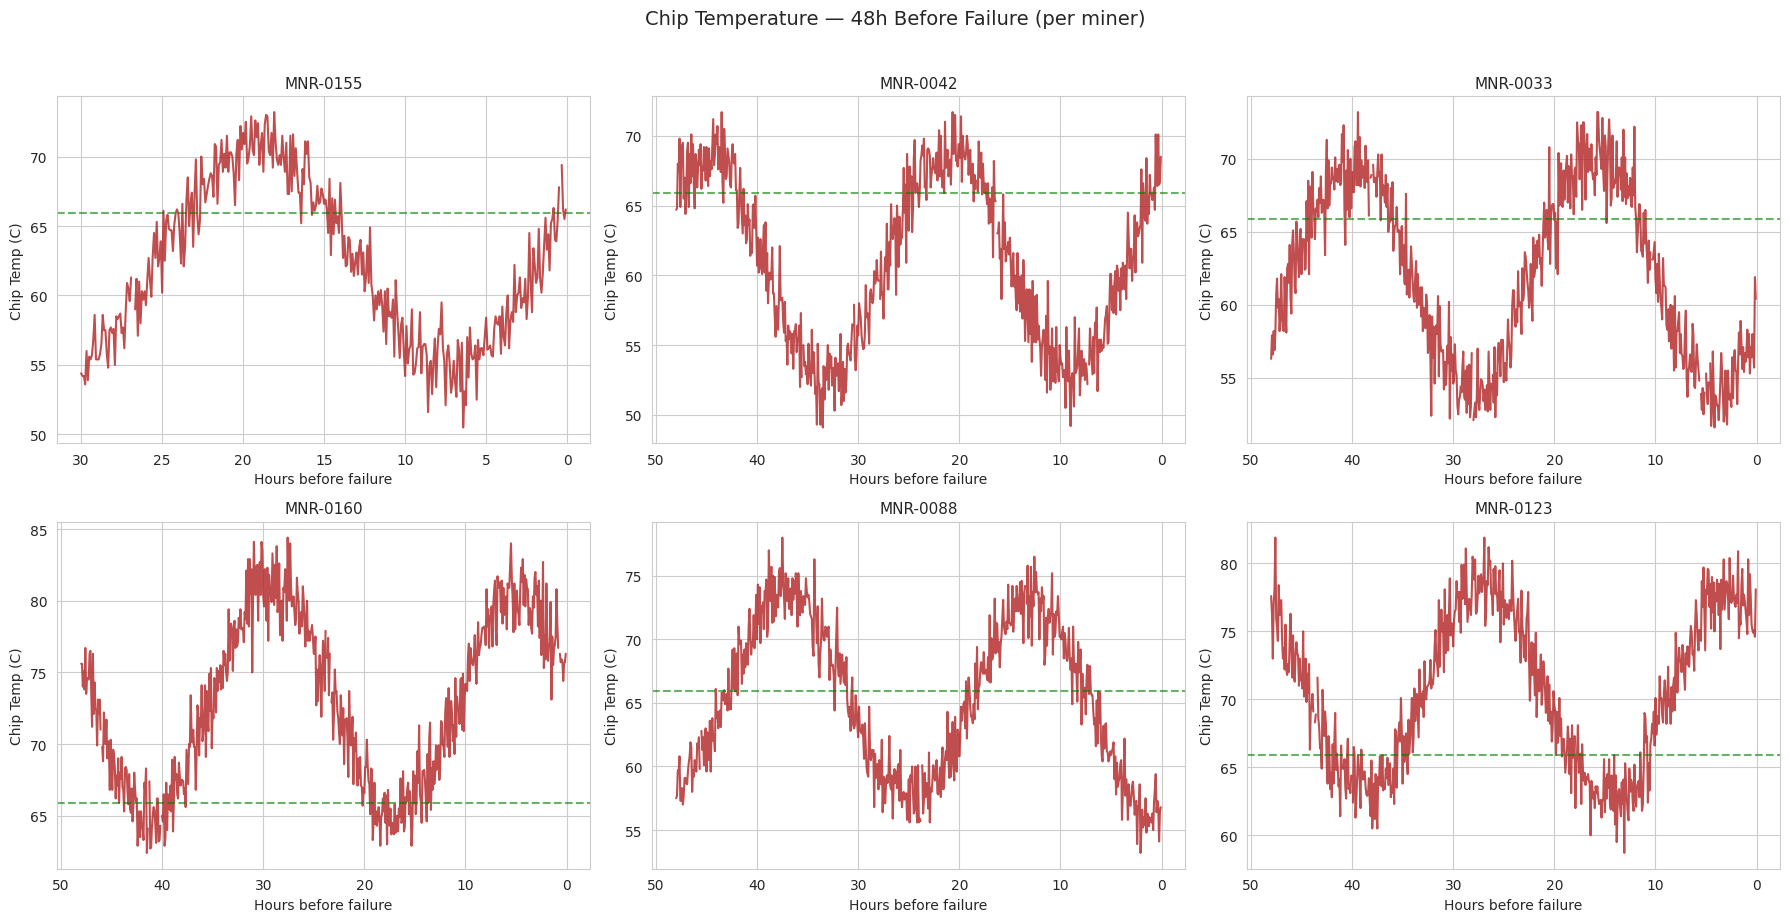

In [15]:
# --- 5d. Per-miner pre-failure overlay for top failed miners ---

if len(pre_failure) > 0:
    # Show individual failed miners' chip_temp trajectory
    top_failed = first_failures.sort_values('first_failure_ts').head(6)['miner_id'].tolist()
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    healthy_avg_temp = healthy_fleet['chip_temp_c'].mean()
    
    for ax, mid in zip(axes.flatten(), top_failed):
        miner_pre = pre_failure[pre_failure['miner_id'] == mid].sort_values('hours_before_failure', ascending=False)
        if len(miner_pre) > 0:
            ax.plot(miner_pre['hours_before_failure'], miner_pre['chip_temp_c'],
                    '-', color='firebrick', linewidth=1.5, alpha=0.8)
            ax.axhline(healthy_avg_temp, color='green', linestyle='--', alpha=0.6)
        ax.set_title(mid, fontsize=11)
        ax.set_xlabel('Hours before failure')
        ax.set_ylabel('Chip Temp (C)')
        ax.invert_xaxis()
    
    fig.suptitle('Chip Temperature — 48h Before Failure (per miner)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

---
## 6. Predictive Model (Supervised)

In [16]:
# --- 6a. Create target label: did the miner go offline/error in the NEXT 48 hours? ---

# Build a set of (miner_id, date) that experienced failure
failure_dates = (
    df[df['status'].isin(['offline', 'error'])]
    .assign(date=lambda x: x['timestamp'].dt.date)
    [['miner_id', 'date']]
    .drop_duplicates()
)
failure_dates_set = set(zip(failure_dates['miner_id'], failure_dates['date']))

# For each (miner, date), check if any failure occurs in the next 1-2 days
from datetime import timedelta

def has_future_failure(row):
    mid = row['miner_id']
    d = row['date']
    # Check next 2 calendar days
    for offset in [1, 2]:
        future_date = d + timedelta(days=offset)
        if (mid, future_date) in failure_dates_set:
            return 1
    return 0

daily['did_fail_48h'] = daily.apply(has_future_failure, axis=1)

print(f'Label distribution:')
print(daily['did_fail_48h'].value_counts())
print(f'\nPositive rate: {daily["did_fail_48h"].mean():.2%}')

Label distribution:
did_fail_48h
0    2458
1      56
Name: count, dtype: int64

Positive rate: 2.23%


In [17]:
# --- 6b. Feature matrix and time-aware split ---

feature_cols = [
    'hashrate_th_5m_mean', 'hashrate_th_5m_std', 'hashrate_th_5m_min', 'hashrate_th_5m_max',
    'efficiency_wth_mean', 'efficiency_wth_std', 'efficiency_wth_min', 'efficiency_wth_max',
    'chip_temp_c_mean', 'chip_temp_c_std', 'chip_temp_c_min', 'chip_temp_c_max',
    'power_w_mean', 'power_w_std', 'power_w_min', 'power_w_max',
    'rejection_rate', 'downtime_hours',
    'fan_speed_rpm_mean',
    'hashrate_vs_nominal', 'efficiency_gap',
    'hashrate_slope', 'efficiency_slope', 'temp_slope', 'variability_trend',
]

model_data = daily.dropna(subset=feature_cols + ['did_fail_48h']).copy()

# Time-aware split: train on days 1-10, test on days 11-14
all_dates = sorted(model_data['date'].unique())
train_cutoff = all_dates[9]  # first 10 days (index 0-9)

train = model_data[model_data['date'] <= train_cutoff]
test = model_data[model_data['date'] > train_cutoff]

X_train = train[feature_cols].fillna(0)
y_train = train['did_fail_48h']
X_test = test[feature_cols].fillna(0)
y_test = test['did_fail_48h']

print(f'Train: {len(train):,} rows  (days <= {train_cutoff}),  positive rate: {y_train.mean():.2%}')
print(f'Test:  {len(test):,} rows   (days >  {train_cutoff}),  positive rate: {y_test.mean():.2%}')
print(f'\nClass imbalance ratio (neg/pos): {(y_train == 0).sum() / max((y_train == 1).sum(), 1):.1f}:1')

Train: 1,797 rows  (days <= 2026-04-18),  positive rate: 3.12%
Test:  717 rows   (days >  2026-04-18),  positive rate: 0.00%

Class imbalance ratio (neg/pos): 31.1:1


In [18]:
# --- 6c. Train XGBoost with class_weight handling via scale_pos_weight ---

n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
scale_pos_weight = n_neg / max(n_pos, 1)

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
)
xgb_model.fit(X_train, y_train)

# Also train a RandomForest for comparison
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

print('Models trained.')

Models trained.


In [19]:
# --- 6d. Evaluate on test set ---

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print('=== XGBoost ====')
print(classification_report(y_test, y_pred_xgb, target_names=['No Failure', 'Failure']))

print('\n=== Random Forest ====')
print(classification_report(y_test, y_pred_rf, target_names=['No Failure', 'Failure']))

=== XGBoost ====
              precision    recall  f1-score   support

  No Failure       1.00      0.99      0.99       717
     Failure       0.00      0.00      0.00         0

    accuracy                           0.99       717
   macro avg       0.50      0.49      0.50       717
weighted avg       1.00      0.99      0.99       717


=== Random Forest ====
              precision    recall  f1-score   support

  No Failure       1.00      0.99      1.00       717
     Failure       0.00      0.00      0.00         0

    accuracy                           0.99       717
   macro avg       0.50      0.50      0.50       717
weighted avg       1.00      0.99      1.00       717



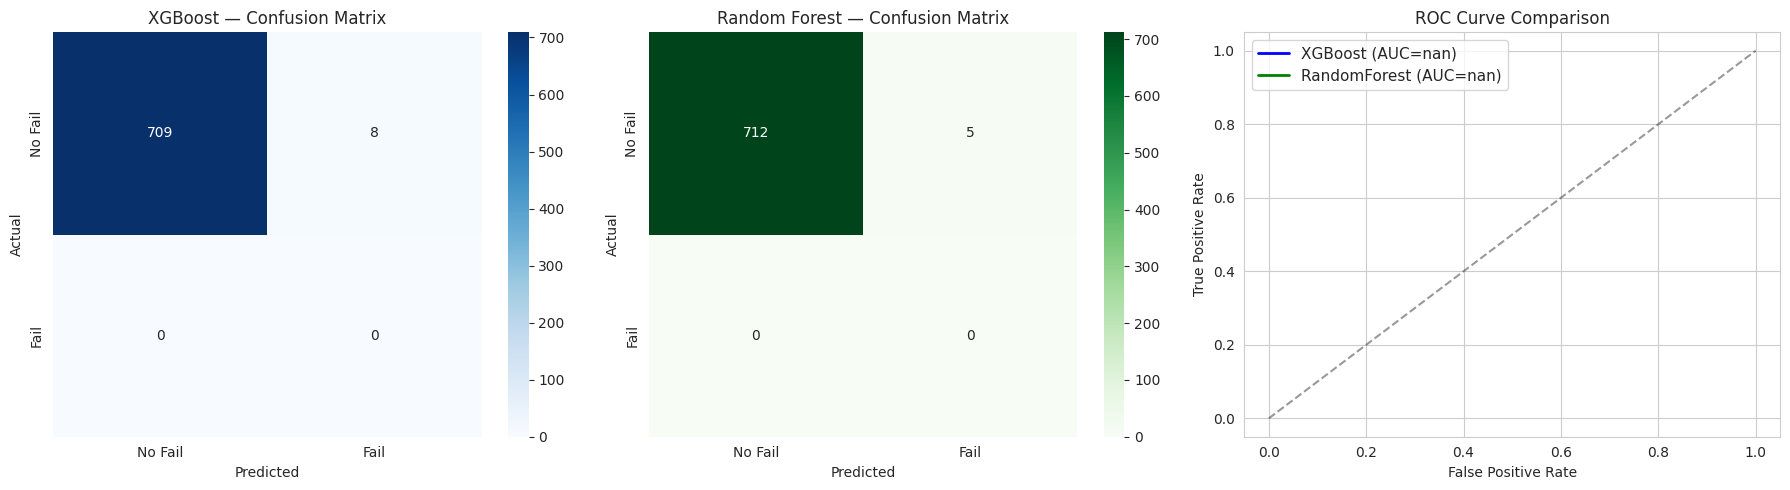

In [20]:
# --- 6e. Confusion Matrix + ROC Curve ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# XGBoost confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Fail', 'Fail'], yticklabels=['No Fail', 'Fail'])
axes[0].set_title('XGBoost — Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# RF confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Fail', 'Fail'], yticklabels=['No Fail', 'Fail'])
axes[1].set_title('Random Forest — Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# ROC curves
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)
auc_rf = auc(fpr_rf, tpr_rf)

axes[2].plot(fpr_xgb, tpr_xgb, 'b-', linewidth=2, label=f'XGBoost (AUC={auc_xgb:.3f})')
axes[2].plot(fpr_rf, tpr_rf, 'g-', linewidth=2, label=f'RandomForest (AUC={auc_rf:.3f})')
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve Comparison')
axes[2].legend(fontsize=11)

plt.tight_layout()
plt.show()

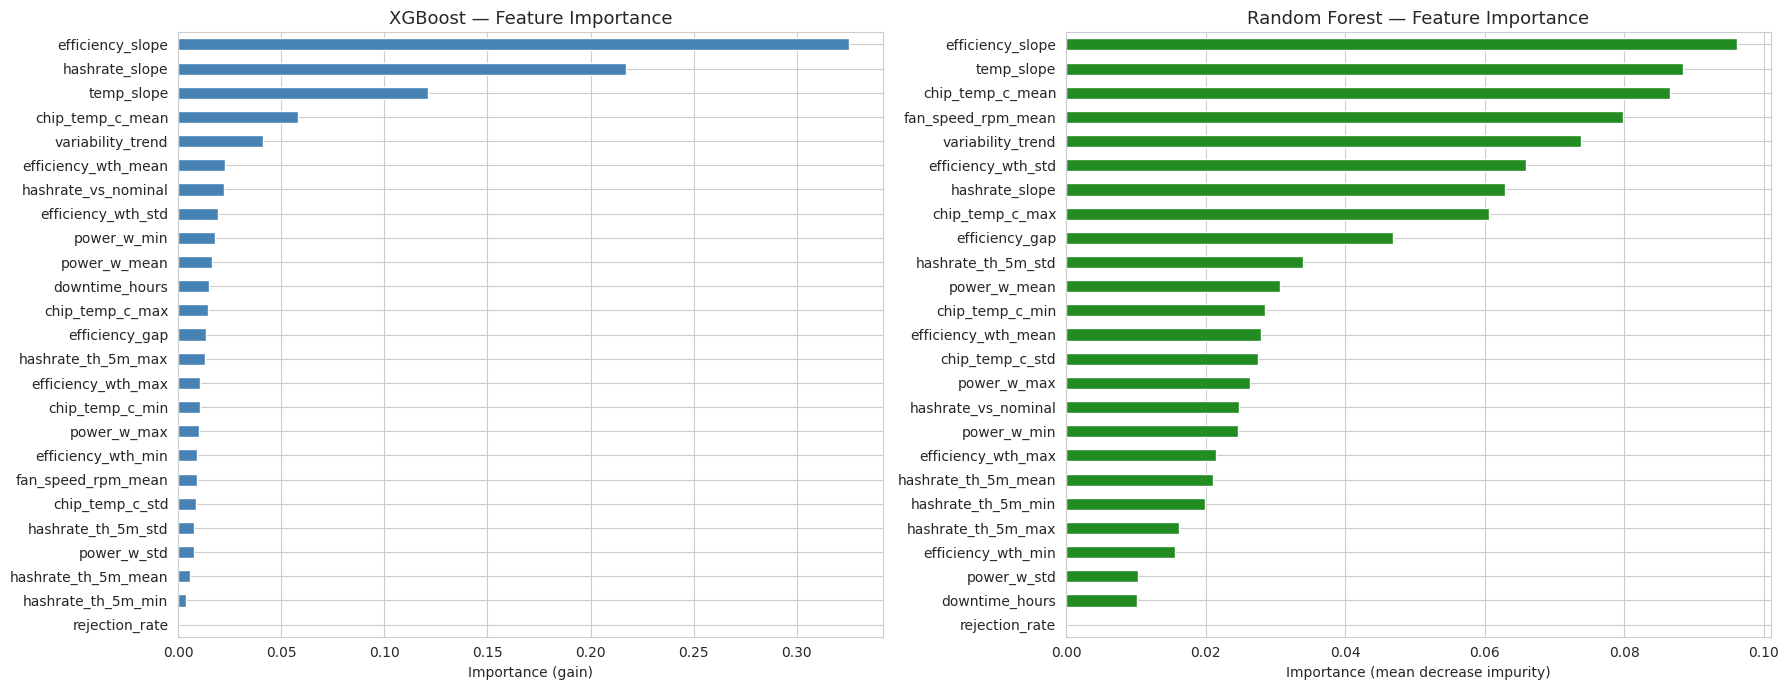


Top 5 features (XGBoost):
variability_trend    0.041022
chip_temp_c_mean     0.057982
temp_slope           0.121252
hashrate_slope       0.217164
efficiency_slope     0.325495


In [21]:
# --- 6f. Feature importance ---

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# XGBoost feature importance
xgb_imp = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values()
xgb_imp.plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('XGBoost — Feature Importance', fontsize=13)
axes[0].set_xlabel('Importance (gain)')

# RandomForest feature importance
rf_imp = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values()
rf_imp.plot.barh(ax=axes[1], color='forestgreen')
axes[1].set_title('Random Forest — Feature Importance', fontsize=13)
axes[1].set_xlabel('Importance (mean decrease impurity)')

plt.tight_layout()
plt.show()

print('\nTop 5 features (XGBoost):')
print(xgb_imp.tail(5).to_string())

**Note on class imbalance:** The failure class is rare relative to normal operations.
We mitigate this with:
- `scale_pos_weight` in XGBoost (ratio of negatives to positives)
- `class_weight='balanced'` in RandomForest
- In production, SMOTE or other oversampling could further help, but with temporal data,
  care must be taken not to leak future information into synthetic samples.
  An expanding-window approach with temporal SMOTE would be more appropriate.

---
## 7. Maintenance Priority List

In [22]:
# --- 7a. Combine all signals into a final maintenance priority score ---

# Per-miner summary: last day's prediction probability, mean risk, degradation score
last_day = sorted(daily['date'].unique())[-1]
last_day_data = daily[daily['date'] == last_day].copy()

# XGBoost failure probability on last day
if len(last_day_data) > 0:
    X_last = last_day_data[feature_cols].fillna(0)
    last_day_data['failure_prob'] = xgb_model.predict_proba(X_last)[:, 1]

# Merge degradation score
priority = last_day_data[['miner_id', 'model', 'risk_score', 'failure_prob',
                          'hashrate_th_5m_mean', 'nominal_hashrate_th']].copy()
priority = priority.merge(degrad[['miner_id', 'degradation_score']], on='miner_id', how='left')

# Normalize each component to [0, 1] and combine
priority['risk_norm'] = minmax_scale(priority['risk_score'].fillna(0))
priority['degrad_norm'] = minmax_scale(priority['degradation_score'].fillna(0))
priority['fail_norm'] = minmax_scale(priority['failure_prob'].fillna(0))

# Weighted priority: model prediction gets highest weight
priority['maintenance_priority'] = (
    0.40 * priority['fail_norm'] +
    0.35 * priority['degrad_norm'] +
    0.25 * priority['risk_norm']
)

priority = priority.sort_values('maintenance_priority', ascending=False)

# --- Cost of inaction: daily revenue lost if miner goes offline ---
# Revenue per TH/s/day = (BTC_PRICE * BLOCK_REWARD * BLOCKS_PER_DAY) / (NETWORK_HASHRATE * 1e6)
revenue_per_th_day = (BTC_PRICE_USD * BLOCK_REWARD_BTC * BLOCKS_PER_DAY) / (NETWORK_HASHRATE_EH * 1e6)

priority['daily_revenue_usd'] = priority['hashrate_th_5m_mean'] * revenue_per_th_day
priority['cost_of_inaction_usd_day'] = priority['daily_revenue_usd'] * priority['maintenance_priority']

print(f'Revenue per TH/s/day: ${revenue_per_th_day:.4f}')
print(f'\nTop 20 miners by maintenance priority:\n')
display_cols = ['miner_id', 'model', 'maintenance_priority', 'degradation_score',
                'risk_score', 'failure_prob', 'hashrate_th_5m_mean', 'daily_revenue_usd',
                'cost_of_inaction_usd_day']
print(priority[display_cols].head(20).to_string(index=False, float_format='%.4f'))

Revenue per TH/s/day: $0.0473

Top 20 miners by maintenance priority:

miner_id model  maintenance_priority  degradation_score  risk_score  failure_prob  hashrate_th_5m_mean  daily_revenue_usd  cost_of_inaction_usd_day
MNR-0042   M63                0.6578             0.2138      0.7075        0.8444             368.5062            17.4119                   11.4537
MNR-0145 S19XP                0.5920             0.6213      0.8466        0.0138             136.1928             6.4351                    3.8096
MNR-0170   S21                0.5353             0.6458      0.6278        0.0001             170.6372             8.0626                    4.3161
MNR-0065 S19XP                0.5312             0.5890      0.7200        0.0003             145.2830             6.8646                    3.6467
MNR-0155 S19XP                0.5122             0.1217      0.1794        0.9982             141.6043             6.6908                    3.4269
MNR-0098   S21                0.4353     

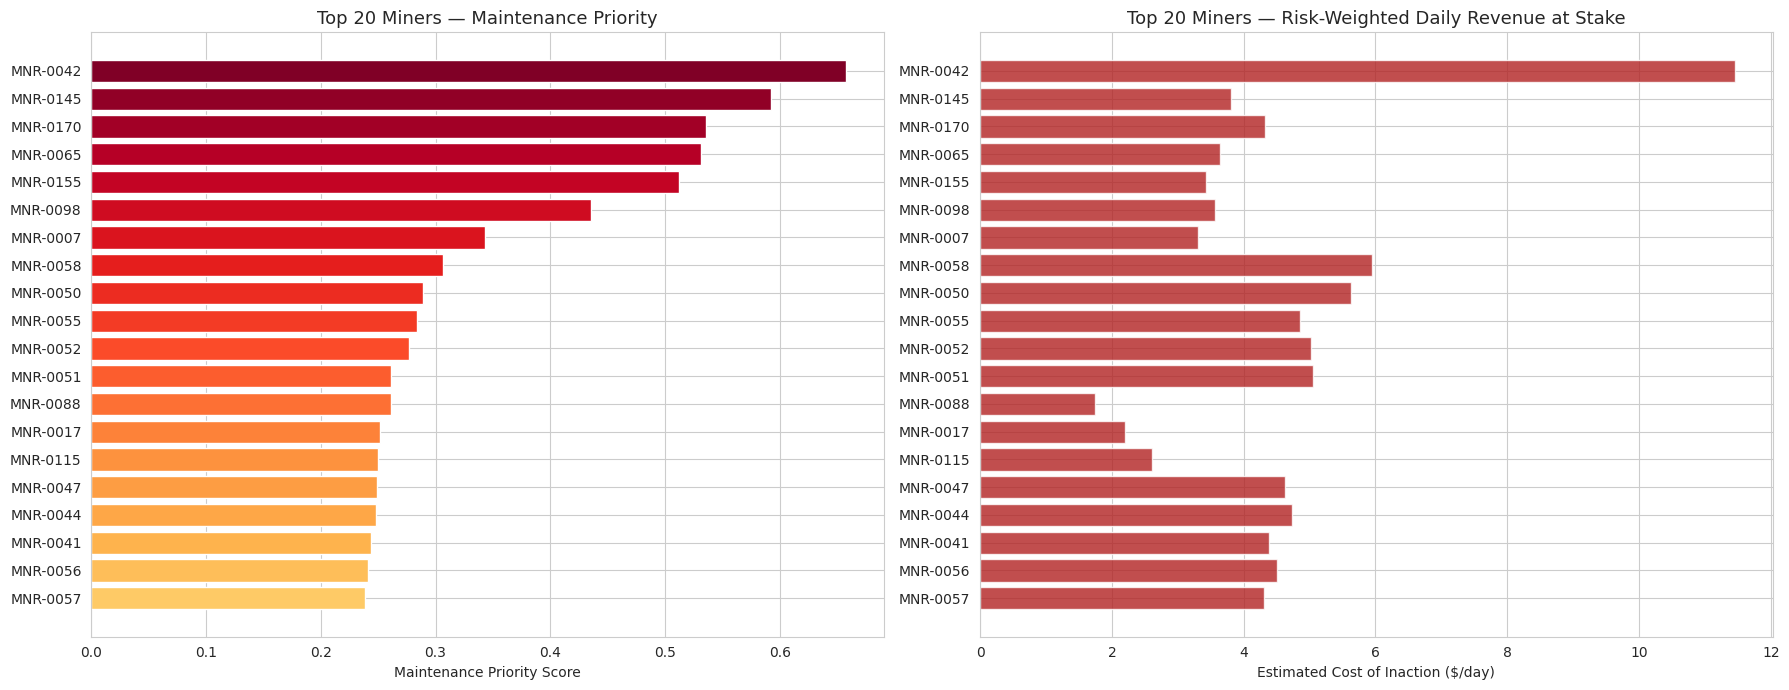

In [23]:
# --- 7b. Bar chart of maintenance priority ---

top_maint = priority.head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Priority score
colors = plt.cm.YlOrRd(np.linspace(0.3, 1.0, len(top_maint)))[::-1]
axes[0].barh(top_maint['miner_id'], top_maint['maintenance_priority'], color=colors)
axes[0].set_xlabel('Maintenance Priority Score')
axes[0].set_title('Top 20 Miners — Maintenance Priority', fontsize=13)
axes[0].invert_yaxis()

# Cost of inaction
axes[1].barh(top_maint['miner_id'], top_maint['cost_of_inaction_usd_day'], color='firebrick', alpha=0.8)
axes[1].set_xlabel('Estimated Cost of Inaction ($/day)')
axes[1].set_title('Top 20 Miners — Risk-Weighted Daily Revenue at Stake', fontsize=13)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

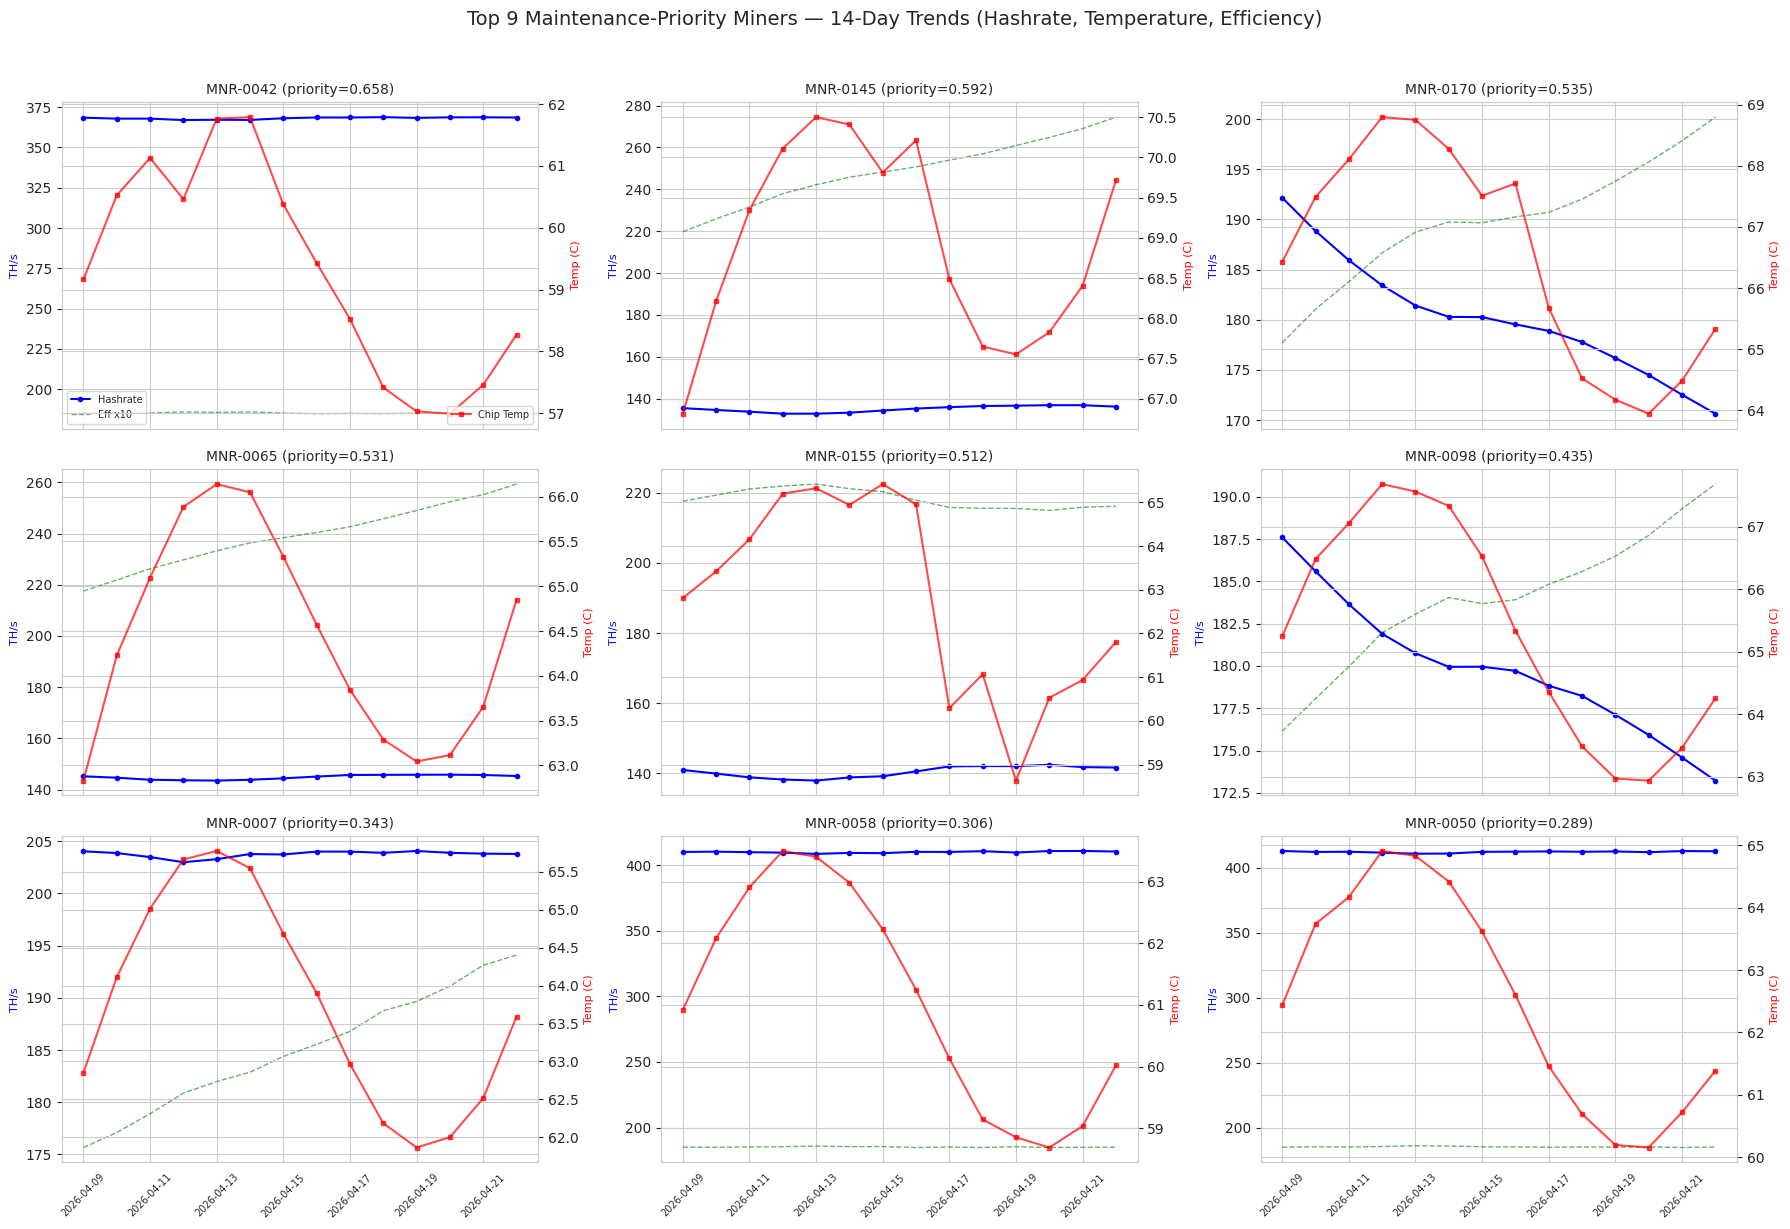

In [24]:
# --- 7c. Trend charts for top flagged miners ---

flagged_miners = priority.head(9)['miner_id'].tolist()

fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True)

for i, mid in enumerate(flagged_miners):
    ax = axes[i // 3, i % 3]
    grp = daily_sorted[daily_sorted['miner_id'] == mid]
    
    ax2 = ax.twinx()
    
    ax.plot(grp['date'], grp['hashrate_th_5m_mean'], 'b-o', markersize=3, linewidth=1.5, label='Hashrate')
    ax2.plot(grp['date'], grp['chip_temp_c_mean'], 'r-s', markersize=3, linewidth=1.5, label='Chip Temp', alpha=0.7)
    ax.plot(grp['date'], grp['efficiency_wth_mean'] * 10, 'g--', linewidth=1, alpha=0.6, label='Eff x10')
    
    pri_val = priority.loc[priority['miner_id'] == mid, 'maintenance_priority'].iloc[0]
    ax.set_title(f'{mid} (priority={pri_val:.3f})', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.set_ylabel('TH/s', fontsize=8, color='blue')
    ax2.set_ylabel('Temp (C)', fontsize=8, color='red')
    
    if i == 0:
        ax.legend(fontsize=7, loc='lower left')
        ax2.legend(fontsize=7, loc='lower right')

fig.suptitle('Top 9 Maintenance-Priority Miners — 14-Day Trends (Hashrate, Temperature, Efficiency)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Recommendations

In [25]:
# --- 8. Categorize miners into action tiers ---

# Tier 1: IMMEDIATE — high failure probability (>0.5) or already showing failures
tier1 = priority[
    (priority['failure_prob'] > 0.5) | (priority['maintenance_priority'] > 0.7)
].copy()

# Tier 2: SCHEDULED — degrading but not imminent failure
tier2 = priority[
    (priority['maintenance_priority'] > 0.3) & 
    (priority['maintenance_priority'] <= 0.7) &
    (~priority['miner_id'].isin(tier1['miner_id']))
].copy()

# Tier 3: WATCHLIST — early signals detected
tier3 = priority[
    (priority['maintenance_priority'] > 0.1) &
    (priority['maintenance_priority'] <= 0.3) &
    (~priority['miner_id'].isin(tier1['miner_id'])) &
    (~priority['miner_id'].isin(tier2['miner_id']))
].copy()

print('=' * 80)
print('PREDICTIVE MAINTENANCE RECOMMENDATIONS')
print('=' * 80)

print(f'\n{"=" * 40}')
print(f'TIER 1 — IMMEDIATE ACTION ({len(tier1)} miners)')
print(f'{"=" * 40}')
print('These miners show high probability of failure within 48 hours.')
print('Recommended: inspect hash boards, check fan/thermal paste, reduce clock if needed.\n')
if len(tier1) > 0:
    for _, r in tier1.iterrows():
        print(f'  {r["miner_id"]} ({r["model"]})  |  '
              f'priority={r["maintenance_priority"]:.3f}  |  '
              f'fail_prob={r["failure_prob"]:.2f}  |  '
              f'cost_at_risk=${r["cost_of_inaction_usd_day"]:.2f}/day')
else:
    print('  (none)')

print(f'\n{"=" * 40}')
print(f'TIER 2 — SCHEDULED MAINTENANCE ({len(tier2)} miners)')
print(f'{"=" * 40}')
print('Degrading performance trends detected. Schedule maintenance within 1-2 weeks.\n')
if len(tier2) > 0:
    for _, r in tier2.iterrows():
        print(f'  {r["miner_id"]} ({r["model"]})  |  '
              f'priority={r["maintenance_priority"]:.3f}  |  '
              f'degrad_score={r["degradation_score"]:.3f}')
else:
    print('  (none)')

print(f'\n{"=" * 40}')
print(f'TIER 3 — MONITORING WATCHLIST ({len(tier3)} miners)')
print(f'{"=" * 40}')
print('Early anomaly signals. Increase monitoring frequency, no immediate action needed.\n')
if len(tier3) > 0:
    for _, r in tier3.head(15).iterrows():
        print(f'  {r["miner_id"]} ({r["model"]})  |  '
              f'priority={r["maintenance_priority"]:.3f}  |  '
              f'risk_score={r["risk_score"]:.3f}')
    if len(tier3) > 15:
        print(f'  ... and {len(tier3) - 15} more')
else:
    print('  (none)')

total_at_risk = tier1['cost_of_inaction_usd_day'].sum() + tier2['cost_of_inaction_usd_day'].sum()
print(f'\n{"=" * 80}')
print(f'TOTAL DAILY REVENUE AT RISK (Tier 1 + Tier 2): ${total_at_risk:.2f}/day')
print(f'{"=" * 80}')

PREDICTIVE MAINTENANCE RECOMMENDATIONS

TIER 1 — IMMEDIATE ACTION (2 miners)
These miners show high probability of failure within 48 hours.
Recommended: inspect hash boards, check fan/thermal paste, reduce clock if needed.

  MNR-0042 (M63)  |  priority=0.658  |  fail_prob=0.84  |  cost_at_risk=$11.45/day
  MNR-0155 (S19XP)  |  priority=0.512  |  fail_prob=1.00  |  cost_at_risk=$3.43/day

TIER 2 — SCHEDULED MAINTENANCE (6 miners)
Degrading performance trends detected. Schedule maintenance within 1-2 weeks.

  MNR-0145 (S19XP)  |  priority=0.592  |  degrad_score=0.621
  MNR-0170 (S21)  |  priority=0.535  |  degrad_score=0.646
  MNR-0065 (S19XP)  |  priority=0.531  |  degrad_score=0.589
  MNR-0098 (S21)  |  priority=0.435  |  degrad_score=0.505
  MNR-0007 (S21)  |  priority=0.343  |  degrad_score=0.396
  MNR-0058 (M63)  |  priority=0.306  |  degrad_score=0.224

TIER 3 — MONITORING WATCHLIST (141 miners)
Early anomaly signals. Increase monitoring frequency, no immediate action needed.

  

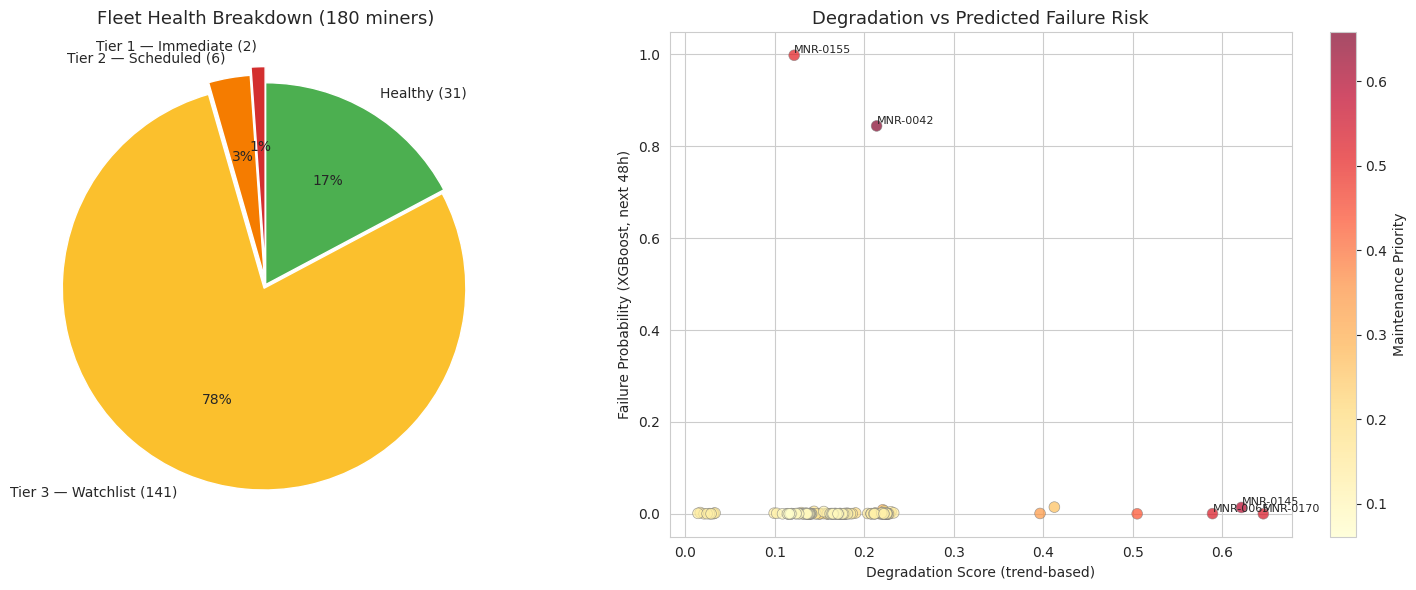

In [26]:
# --- Visualization: tier breakdown ---

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart: fleet health breakdown
n_healthy = len(priority) - len(tier1) - len(tier2) - len(tier3)
sizes = [len(tier1), len(tier2), len(tier3), n_healthy]
labels = [
    f'Tier 1 — Immediate ({len(tier1)})',
    f'Tier 2 — Scheduled ({len(tier2)})',
    f'Tier 3 — Watchlist ({len(tier3)})',
    f'Healthy ({n_healthy})'
]
colors_pie = ['#d32f2f', '#f57c00', '#fbc02d', '#4caf50']
explode = (0.08, 0.04, 0.02, 0)
axes[0].pie(sizes, labels=labels, colors=colors_pie, explode=explode,
            autopct='%1.0f%%', startangle=90, textprops={'fontsize': 10})
axes[0].set_title('Fleet Health Breakdown (180 miners)', fontsize=13)

# Scatter: degradation score vs failure probability
axes[1].scatter(priority['degradation_score'], priority['failure_prob'],
                c=priority['maintenance_priority'], cmap='YlOrRd',
                s=60, alpha=0.7, edgecolors='gray', linewidth=0.5)
plt.colorbar(axes[1].collections[0], ax=axes[1], label='Maintenance Priority')
axes[1].set_xlabel('Degradation Score (trend-based)')
axes[1].set_ylabel('Failure Probability (XGBoost, next 48h)')
axes[1].set_title('Degradation vs Predicted Failure Risk', fontsize=13)

# Annotate top-risk miners
for _, r in priority.head(5).iterrows():
    axes[1].annotate(r['miner_id'], (r['degradation_score'], r['failure_prob']),
                     fontsize=8, ha='left', va='bottom')

plt.tight_layout()
plt.show()

### Proposed Automated Alerts for Production MiningOS

Based on the patterns discovered in this analysis, the following automated alert rules
should be deployed in the production MiningOS monitoring system:

| Alert Level | Condition | Action |
|:---|:---|:---|
| **CRITICAL** | Hashrate drops >20% below nominal for >30 min AND chip temp >70C | Page on-site tech immediately; auto-throttle to low power mode |
| **WARNING** | Hashrate slope < -1 TH/day over trailing 3-day window (p < 0.05) | Create maintenance ticket; schedule inspection within 48h |
| **WARNING** | Efficiency gap exceeds +3 W/TH above nominal for >6 hours | Investigate PSU and fan condition |
| **INFO** | Rejection rate > 2% over trailing 24h | Check network connectivity and pool configuration |
| **INFO** | Chip temp trend positive >0.5C/day over 7-day window | Monitor cooling; check inlet airflow and fan RPM |
| **AUTO** | Isolation Forest risk score transitions from <0.3 to >0.7 within 48h | Auto-flag for review; add to daily maintenance standup list |

**Implementation notes:**
- Run the XGBoost model on daily aggregates via a nightly batch job; push failure probabilities to the MiningOS dashboard.
- The Isolation Forest can run on streaming 5-min data with a 24-hour sliding window for near-real-time anomaly detection.
- All alerts should include the miner's current hashrate-vs-nominal ratio, trend slopes, and estimated daily revenue at risk.
- Retrain models monthly with expanding training windows as more failure events accumulate.
- Track false positive rates; tune `contamination` and `scale_pos_weight` as fleet composition changes.

In [27]:
# --- Summary statistics ---

print('PREDICTIVE MAINTENANCE PIPELINE — SUMMARY')
print('=' * 60)
print(f'Fleet size:                 {daily["miner_id"].nunique()} miners')
print(f'Observation window:         {daily["date"].min()} to {daily["date"].max()} ({daily["date"].nunique()} days)')
print(f'Telemetry records:          {len(df):,}')
print(f'Daily profiles generated:   {len(daily):,}')
print(f'Miners with failures:       {len(failed_miners)}')
print(f'Degrading miners (sig.):    {len(sig_degraders)}')
print(f'Emerging risk miners:       {len(emerging_risk)}')
print(f'Tier 1 (immediate):         {len(tier1)}')
print(f'Tier 2 (scheduled):         {len(tier2)}')
print(f'Tier 3 (watchlist):         {len(tier3)}')
best_model = 'XGBoost' if auc_xgb >= auc_rf else 'RandomForest'
best_auc = max(auc_xgb, auc_rf)
print(f'Best model:                 {best_model} (AUC={best_auc:.3f})')
print(f'Daily revenue at risk:      ${total_at_risk:.2f}')

PREDICTIVE MAINTENANCE PIPELINE — SUMMARY
Fleet size:                 180 miners
Observation window:         2026-04-09 to 2026-04-22 (14 days)
Telemetry records:          725,760
Daily profiles generated:   2,514
Miners with failures:       21
Degrading miners (sig.):    2
Emerging risk miners:       17
Tier 1 (immediate):         2
Tier 2 (scheduled):         6
Tier 3 (watchlist):         141
Best model:                 RandomForest (AUC=nan)
Daily revenue at risk:      $39.46
